# Number Labyrinth — Full Board Generation

This notebook develops the complete board-generation algorithm:

1. **Path generation** — `generate_solution_path_dfs` from `generator_analysis.ipynb`.
2. **Path value assignment** — ascending sequence with random step in `[MIN_STEP, MAX_STEP]`.
3. **Non-path fill** — BFS wave-based flood-fill that propagates values outward from the path, using an A/B labelling scheme to control value direction.
4. **Display** — render completed boards with numbers and labels; highlight the solution path.

---

### Movement rule
A move from cell X to adjacent cell Y is allowed iff `value(X) < value(Y)`.  
A valid path from start `(0,0)` to goal `(cols-1, rows-1)` is a strictly-increasing walk.

### Fill algorithm overview
All path cells are initially labelled **A**.  
Each wave assigns labels to newly filled cells according to their numbered neighbours:

| # numbered neighbours | Condition | Value assigned | New label |
|---|---|---|---|
| 1 | neighbour is **A** or **B** | +step (prob P_HIGHER) / −step | A (if +) / B (if −) |
| 2 | both neighbours **A** | higher than both | B |
| 2 | at least one neighbour **B** | between the two (if room) | A |
| 2 | at least one neighbour **B**, no room between | smaller than both | B |
| 2 | at least one neighbour **B**, can't go smaller | larger than both | A |
| 3+ | any | smaller than all adjacent | B |

Step size sampled uniformly from `[MIN_STEP, MAX_STEP]` — the same range used for the path.

Uniqueness of the solution path is **not** guaranteed by this algorithm.

---
## 0 · Imports & global parameters

In [1]:
import random
import math
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Tunable parameters ────────────────────────────────────────────────────────
MIN_STEP = 1    # minimum step size along path and for non-path value propagation
MAX_STEP = 20   # maximum step size
BASE_MIN = 1    # minimum starting value for the first path cell
BASE_MAX = 20   # maximum starting value for the first path cell
P_HIGHER = 0.5  # probability of going higher when first leaving the path (case 1)

# ── Level config ──────────────────────────────────────────────────────────────
LEVELS = {
    1: dict(cols=4, rows=5,  min_val=1, max_val=120),
    2: dict(cols=5, rows=5,  min_val=1, max_val=300),
    3: dict(cols=6, rows=6,  min_val=1, max_val=500),
    4: dict(cols=7, rows=7,  min_val=1, max_val=700),
    5: dict(cols=8, rows=8,  min_val=1, max_val=999),
}

DIRS = [(1, 0), (-1, 0), (0, 1), (0, -1)]

---
## 1 · DFS solution-path generator

Copied verbatim from `generator_analysis.ipynb`.  
Returns one valid self-avoiding path from `(0,0)` to `(cols-1, rows-1)` satisfying the **neighbour-count rule** (intermediate cells have exactly 2 path-neighbours; endpoints have 1).

In [ ]:
def generate_solution_path_dfs(cols, rows, min_length=None, max_length=None, rng=None):
    """
    DFS single-path generator satisfying the neighbour-count rule.
    Returns a tuple of (col, row) pairs, or None if no path is found.
    """
    if rng is None:
        rng = random

    start = (0, 0)
    goal  = (cols - 1, rows - 1)

    def neighbors(c, r):
        return [(c+dc, r+dr) for dc, dr in DIRS
                if 0 <= c+dc < cols and 0 <= r+dr < rows]

    def manhattan(c, r):
        return abs(goal[0]-c) + abs(goal[1]-r)

    stack = [(start, frozenset([start]), (start,))]
    while stack:
        pos, visited, path = stack.pop()
        cands = list(neighbors(*pos))
        rng.shuffle(cands)
        for nc in cands:
            if nc in visited:
                continue
            if any(nb in visited and nb != pos for nb in neighbors(*nc)):
                continue
            new_len = len(path) + 1
            if max_length is not None and new_len + manhattan(*nc) > max_length:
                continue
            new_path    = path + (nc,)
            new_visited = visited | {nc}
            if nc == goal:
                if min_length is None or new_len >= min_length:
                    return new_path
            else:
                stack.append((nc, new_visited, new_path))
    return None


def get_path(cols, rows, min_pct=0.35, max_pct=0.55, rng=None):
    """Generate one path with length in [min_pct, max_pct] of total cells."""
    T  = cols * rows
    lo = math.floor(min_pct * T)
    hi = math.floor(max_pct * T)
    return generate_solution_path_dfs(cols, rows, min_length=lo, max_length=hi, rng=rng)


# Smoke test
for lvl, cfg in LEVELS.items():
    p = get_path(cfg['cols'], cfg['rows'], rng=random.Random(lvl))
    print(f"Level {lvl}  ({cfg['cols']}×{cfg['rows']})  path len={len(p)}  ends at {p[-1]}")

---
## 2 · Assign values to path cells

$$
v_0 = \text{base},
\qquad
v_{i+1} = v_i + \delta_i,
\qquad
\delta_i \sim \mathrm{Uniform}(\texttt{MIN\_STEP},\, \texttt{MAX\_STEP})
$$

In [3]:
def assign_path_values(path, min_step=None, max_step=None, base_val=None, rng=None):
    """
    Assign strictly increasing integer values to path cells.

    Returns
    -------
    dict  (col, row) -> int
    """
    if min_step is None: min_step = MIN_STEP
    if max_step is None: max_step = MAX_STEP
    if rng is None:      rng = random
    if base_val is None: base_val = rng.randint(BASE_MIN, BASE_MAX)

    values  = {}
    current = base_val
    for cell in path:
        values[cell] = current
        current += rng.randint(min_step, max_step)
    return values


# Demo
for lvl, cfg in LEVELS.items():
    rng  = random.Random(lvl * 100)
    path = get_path(cfg['cols'], cfg['rows'], rng=random.Random(lvl))
    pv   = assign_path_values(path, rng=rng)
    seq  = [pv[c] for c in path]
    steps = [seq[i+1]-seq[i] for i in range(len(seq)-1)]
    print(f"Level {lvl}  len={len(path):2d}  "
          f"values [{seq[0]}…{seq[-1]}]  "
          f"steps min={min(steps)} max={max(steps)} mean={sum(steps)/len(steps):.1f}")

Level 1  len=10  values [5…119]  steps min=4 max=18 mean=12.7
Level 2  len= 9  values [2…66]  steps min=1 max=20 mean=8.0
Level 3  len=17  values [20…214]  steps min=1 max=19 mean=12.1
Level 4  len=23  values [10…270]  steps min=1 max=20 mean=11.8
Level 5  len=29  values [15…299]  steps min=1 max=20 mean=10.1


---
## 3 · BFS wave fill — `fill_board`

### Full procedure

**Step 1.** Generate and number the solution path. Label every path cell **A**. All other cells are unnumbered.

**Step 2.** Let `numbered_fields` be the set of all cells that already have a value.  
Collect `neighbor_batch` = every unnumbered cell adjacent to `numbered_fields` (the current frontier).  
The membership of `numbered_fields` is **snapshotted** before processing the batch — cells assigned within the same wave do not affect each other.

**Step 3.** For each cell `f` in `neighbor_batch`:

- **If `f` is adjacent to exactly 1 cell** in `numbered_fields` (whether labelled A or B):  
  with prob `P_HIGHER` → assign `value + step`, label **A**;  
  otherwise → assign `value − step`, label **B**.

- **If `f` is adjacent to exactly 2 cells** in `numbered_fields`:  
  - **Case 1** — both are labelled **A**: assign a value higher than both, label **B**.  
  - **Case 2** — at least one is labelled **B**:  
    1. If there is an integer strictly between the two neighbours' values → pick one, label **A**.  
    2. Else if `global_min` allows going below both → assign smaller than both, label **B**.  
    3. Else → assign larger than both, label **A**.

- **If `f` is adjacent to 3 or more cells** in `numbered_fields`:  
  assign a value smaller than the minimum of all adjacent values, label **B**.

In all cases `step ~ Uniform(MIN_STEP, MAX_STEP)`. Values are clamped to `[global_min, global_max]`.

**Step 4.** Repeat Steps 2–3 until all cells are numbered.

In [ ]:
def fill_board(
    cols, rows, path, path_values,
    p_higher   = None,
    min_step   = None,
    max_step   = None,
    global_min = 1,
    global_max = 999,
    uniqueness = 'none',   # 'none' | 'weak' | 'strong'
    rng        = None,
):
    """
    Fill every non-path cell using the BFS wave labelling procedure.

    uniqueness
    ----------
    'none'   — no extra constraint (original behaviour)
    'weak'   — no two adjacent cells may share the same value;
               returns (None, None) if a cell cannot be assigned
    'strong' — all values on the board must be distinct;
               returns (None, None) if a cell cannot be assigned

    Returns
    -------
    board  : dict (col,row) -> int   — None on blocking failure
    labels : dict (col,row) -> 'A'|'B' — None on blocking failure
    """
    if p_higher is None: p_higher = P_HIGHER
    if min_step is None: min_step = MIN_STEP
    if max_step is None: max_step = MAX_STEP
    if rng      is None: rng      = random

    board  = dict(path_values)
    labels = {cell: 'A' for cell in path}

    def adj(c, r):
        return [(c+dc, r+dr) for dc, dr in DIRS
                if 0 <= c+dc < cols and 0 <= r+dr < rows]

    def sample_step():
        return rng.randint(min_step, max_step)

    def clamp(v):
        return max(global_min, min(global_max, v))

    # ── Constrained helpers (used when uniqueness != 'none') ──────────────────
    def crange(lo, hi):
        """Integers in [lo, hi] clamped to [global_min, global_max]."""
        return list(range(max(global_min, lo), min(global_max, hi) + 1))

    def valid_pool(pool, cell):
        """Remove values that violate the uniqueness constraint."""
        if not pool:
            return pool
        if uniqueness == 'weak':
            bad = {board[n] for n in adj(*cell) if n in board}
        else:                          # 'strong'
            bad = set(board.values())
        return [v for v in pool if v not in bad]

    # ── BFS wave loop ─────────────────────────────────────────────────────────
    while len(board) < cols * rows:

        snapshot = set(board.keys())
        neighbor_batch = {
            nc
            for cell in snapshot
            for nc in adj(*cell)
            if nc not in snapshot
        }
        if not neighbor_batch:
            break

        for cell in neighbor_batch:
            numbered_nbrs = [n for n in adj(*cell) if n in snapshot]
            n_nbrs = len(numbered_nbrs)

            # ── Unconstrained path (original logic, no behaviour change) ──────
            if uniqueness == 'none':
                if n_nbrs == 1:
                    nbr_val = board[numbered_nbrs[0]]
                    if rng.random() < p_higher:
                        new_val, new_label = clamp(nbr_val + sample_step()), 'A'
                    else:
                        new_val, new_label = clamp(nbr_val - sample_step()), 'B'

                elif n_nbrs == 2:
                    v0, v1 = board[numbered_nbrs[0]], board[numbered_nbrs[1]]
                    l0, l1 = labels[numbered_nbrs[0]], labels[numbered_nbrs[1]]
                    lo, hi = min(v0, v1), max(v0, v1)
                    if l0 == 'A' and l1 == 'A':
                        new_val, new_label = clamp(hi + sample_step()), 'B'
                    else:
                        if hi - lo >= 2:
                            new_val, new_label = rng.randint(lo + 1, hi - 1), 'A'
                        elif clamp(lo - sample_step()) < lo:
                            new_val, new_label = clamp(lo - sample_step()), 'B'
                        else:
                            new_val, new_label = clamp(hi + sample_step()), 'A'

                else:
                    min_adj = min(board[n] for n in numbered_nbrs)
                    new_val, new_label = clamp(min_adj - sample_step()), 'B'

            # ── Constrained path (weak / strong) ──────────────────────────────
            else:
                new_val = new_label = None

                if n_nbrs == 1:
                    nbr_val = board[numbered_nbrs[0]]
                    if rng.random() < p_higher:
                        pool = valid_pool(crange(nbr_val + min_step, nbr_val + max_step), cell)
                        if not pool: return None, None
                        new_val, new_label = rng.choice(pool), 'A'
                    else:
                        pool = valid_pool(crange(nbr_val - max_step, nbr_val - min_step), cell)
                        if not pool: return None, None
                        new_val, new_label = rng.choice(pool), 'B'

                elif n_nbrs == 2:
                    v0, v1 = board[numbered_nbrs[0]], board[numbered_nbrs[1]]
                    l0, l1 = labels[numbered_nbrs[0]], labels[numbered_nbrs[1]]
                    lo, hi = min(v0, v1), max(v0, v1)

                    if l0 == 'A' and l1 == 'A':
                        pool = valid_pool(crange(hi + min_step, hi + max_step), cell)
                        if not pool: return None, None
                        new_val, new_label = rng.choice(pool), 'B'
                    else:
                        # 1. between
                        if hi - lo >= 2:
                            pool = valid_pool(list(range(lo + 1, hi)), cell)
                            if pool:
                                new_val, new_label = rng.choice(pool), 'A'
                        # 2. smaller than both
                        if new_val is None:
                            pool = valid_pool(
                                [v for v in crange(lo - max_step, lo - min_step) if v < lo],
                                cell,
                            )
                            if pool:
                                new_val, new_label = rng.choice(pool), 'B'
                        # 3. larger than both
                        if new_val is None:
                            pool = valid_pool(crange(hi + min_step, hi + max_step), cell)
                            if pool:
                                new_val, new_label = rng.choice(pool), 'A'
                        if new_val is None:
                            return None, None

                else:  # 3+ neighbours
                    min_adj = min(board[n] for n in numbered_nbrs)
                    pool = valid_pool(
                        [v for v in crange(min_adj - max_step, min_adj - min_step) if v < min_adj],
                        cell,
                    )
                    if not pool: return None, None
                    new_val, new_label = rng.choice(pool), 'B'

            board[cell]  = new_val
            labels[cell] = new_label

    return board, labels


print("fill_board defined.")

### 3.1 · Sanity check — print one board with labels

In [5]:
def print_board(cols, rows, board, path, labels=None):
    """Print the board as a text grid.  * marks path cells; A/B marks non-path labels."""
    path_set = set(path)
    print("    " + "".join(f"{c:6d}" for c in range(cols)))
    for r in range(rows):
        row_str = f"{r:2d}  "
        for c in range(cols):
            v = board[(c, r)]
            if (c, r) in path_set:
                marker = ' *'
            elif labels:
                lbl = labels.get((c, r), '?')
                marker = f' {lbl}' if lbl else '  '
            else:
                marker = '  '
            row_str += f"{marker}{v:4d}"
        print(row_str)
    print("  (* = path   A = higher / between   B = lower / higher-than-two-A)\n")


# ── Example: Level 1, seed 42 ─────────────────────────────────────────────────
rng  = random.Random(42)
cfg  = LEVELS[1]
path = get_path(cfg['cols'], cfg['rows'], rng=rng)
pv   = assign_path_values(path, rng=rng)
bd, lbl = fill_board(
    cfg['cols'], cfg['rows'], path, pv,
    global_min=cfg['min_val'], global_max=cfg['max_val'],
    rng=rng,
)

print(f"Level 1 (seed=42)  path={len(path)} cells  "
      f"v_start={pv[path[0]]}  v_goal={pv[path[-1]]}\n")
print_board(cfg['cols'], cfg['rows'], bd, path, lbl)

# Label distribution
from collections import Counter
non_path_labels = {k: v for k, v in lbl.items() if k not in set(path)}
cnt = Counter(non_path_labels.values())
print(f"Non-path label counts: {dict(cnt)}")
print(f"Value range on board:  [{min(bd.values())}–{max(bd.values())}]")

Level 1 (seed=42)  path=10 cells  v_start=18  v_goal=115

         0     1     2     3
 0   *  18 *  25 *  43 *  57
 1   A  23 A  29 B  39 *  65
 2   B 120 A 110 *  99 *  80
 3   B  97 A 110 * 108 B  60
 4   A 120 A 120 * 109 * 115
  (* = path   A = higher / between   B = lower / higher-than-two-A)

Non-path label counts: {'A': 6, 'B': 4}
Value range on board:  [18–120]


---
## 4 · Board display

Each cell shows its numeric value.  
Path cells (green) additionally show the step index (small, top) and value (bold, bottom).  
Non-path cells (beige) show the value at centre and a small label letter in the corner:
- **A** — went *higher* when first leaving the path (orange)
- **B** — went *lower* off path/A, or *higher* off another B (steel blue)

In [6]:
LABEL_COLOR = {'A': '#c05000', 'B': '#1a4fa0'}

def display_board(cols, rows, board, path=None, labels=None, title=None, ax=None):
    """
    Render the full board with values and optional labels.

    Parameters
    ----------
    cols, rows : board dimensions
    board      : dict (col,row)->int
    path       : optional solution path list[(col,row)]
    labels     : optional dict (col,row)->None|'A'|'B' from fill_board_bfs
    title      : optional title string
    ax         : optional existing Axes
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(cols * 1.05, rows * 1.05))

    path_set   = set(path) if path else set()
    path_index = {cell: i for i, cell in enumerate(path)} if path else {}
    n_path     = len(path) if path else 0

    for r in range(rows):
        for c in range(cols):
            is_path = (c, r) in path_set
            checker = (c + r) % 2 == 0

            # ── Cell background ─────────────────────────────────────────────
            if is_path:
                face = '#b6e8b6' if checker else '#8fd98f'
            else:
                face = '#f5e6d0' if checker else '#e8d5b7'

            rect = mpatches.FancyBboxPatch(
                (c, rows - 1 - r), 1, 1,
                boxstyle='square,pad=0',
                linewidth=0.7, edgecolor='#aaa', facecolor=face,
            )
            ax.add_patch(rect)

            val = board.get((c, r), '')
            y0  = rows - 1 - r  # bottom-left y of cell in plot coords

            if is_path:
                # Step index — small, upper half
                idx = path_index[(c, r)]
                step_lbl = 'S' if idx == 0 else ('G' if idx == n_path - 1 else str(idx))
                ax.text(c + 0.5, y0 + 0.70, step_lbl,
                        ha='center', va='center', fontsize=6.5, color='#1a5c1a')
                # Value — bold, lower half
                ax.text(c + 0.5, y0 + 0.30, str(val),
                        ha='center', va='center', fontsize=9,
                        fontweight='bold', color='#0a3a0a')
            else:
                # Value — centre
                ax.text(c + 0.5, y0 + 0.50, str(val),
                        ha='center', va='center', fontsize=9, color='#5a3010')
                # Label — small, bottom-right corner
                if labels:
                    lbl = labels.get((c, r))
                    if lbl:
                        ax.text(c + 0.88, y0 + 0.12, lbl,
                                ha='center', va='center',
                                fontsize=6, fontweight='bold',
                                color=LABEL_COLOR.get(lbl, '#888'))

    # ── Path arrows ───────────────────────────────────────────────────────────
    if path:
        for i in range(len(path) - 1):
            c1, r1 = path[i];  c2, r2 = path[i + 1]
            ax.annotate(
                '', xy=(c2+0.5, rows-1-r2+0.5), xytext=(c1+0.5, rows-1-r1+0.5),
                arrowprops=dict(arrowstyle='->', color='#2a7a2a',
                                lw=1.3, shrinkA=14, shrinkB=14),
            )

    # ── Axis cosmetics ────────────────────────────────────────────────────────
    ax.set_xlim(0, cols);  ax.set_ylim(0, rows)
    ax.set_aspect('equal');  ax.axis('off')
    for c in range(cols):
        ax.text(c+0.5, rows+0.1, str(c), ha='center', va='bottom',
                fontsize=6.5, color='#999')
    for r in range(rows):
        ax.text(-0.1, rows-1-r+0.5, str(r), ha='right', va='center',
                fontsize=6.5, color='#999')
    if title:
        ax.set_title(title, fontsize=9, pad=4)
    if standalone:
        plt.tight_layout();  plt.show()

print("display_board defined.")

display_board defined.


---
## 5 · Example boards — one per level (levels 1–5)

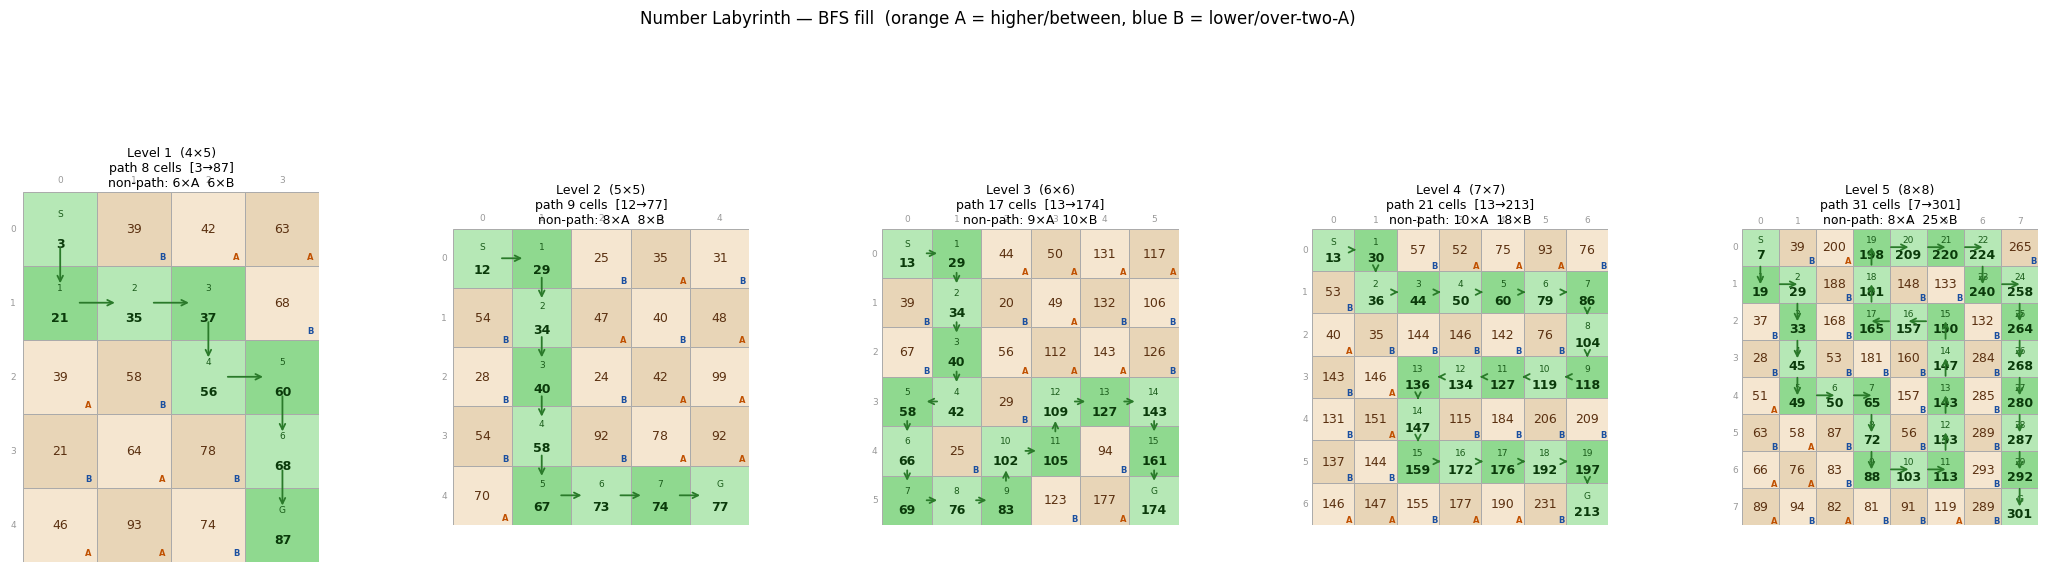

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(26, 7), gridspec_kw={'wspace': 0.45})

for ax, (lvl, cfg) in zip(axes, LEVELS.items()):
    cols, rows = cfg['cols'], cfg['rows']
    rng  = random.Random(lvl * 7)
    path = get_path(cols, rows, rng=rng)
    pv   = assign_path_values(path, rng=rng)
    bd, lbl = fill_board(
        cols, rows, path, pv,
        global_min=cfg['min_val'], global_max=cfg['max_val'],
        rng=rng,
    )
    cnt = Counter(v for k, v in lbl.items() if k not in set(path))
    display_board(
        cols, rows, bd, path, lbl,
        title=(
            f"Level {lvl}  ({cols}×{rows})\n"
            f"path {len(path)} cells  [{pv[path[0]]}→{pv[path[-1]]}]\n"
            f"non-path: {cnt.get('A',0)}×A  {cnt.get('B',0)}×B"
        ),
        ax=ax,
    )

plt.suptitle(
    'Number Labyrinth — BFS fill  (orange A = higher/between, blue B = lower/over-two-A)',
    fontsize=12, y=1.02,
)
plt.show()

In [ ]:
def generate_number_labyrinth_board(
    cols,
    rows,
    min_pct        = 0.35,
    max_pct        = 0.45,
    p_higher       = 0.75,
    # ── solution-path value steps ──────────────────────────────────────────
    path_min_step  = 3,      # min step between consecutive path values
    path_max_step  = 5,      # max step between consecutive path values
    # ── non-path fill steps ────────────────────────────────────────────────
    fill_min_step  = 1,      # min step when propagating values off the path
    fill_max_step  = 25,     # max step when propagating values off the path
    # ── shared ────────────────────────────────────────────────────────────
    base_val       = None,
    global_min     = 1,
    global_max     = 999,
    uniqueness     = 'none',   # 'none' | 'weak' | 'strong'
    rng            = None,
):
    """
    Generate a complete Number Labyrinth board.

    Path values are assigned with ``path_min_step`` / ``path_max_step``.
    Non-path cells are filled with ``fill_min_step`` / ``fill_max_step``.
    Only ``cols`` and ``rows`` are mandatory.

    Returns a dict with keys cols, rows, path, path_values, board, labels,
    or None if path generation fails or fill_board is blocked by the
    uniqueness constraint.
    """
    if rng is None:
        rng = random.Random()

    T  = cols * rows
    lo = math.floor(min_pct * T)
    hi = math.floor(max_pct * T)

    path = generate_solution_path_dfs(cols, rows, min_length=lo, max_length=hi, rng=rng)
    if path is None:
        return None

    path_values = assign_path_values(
        path,
        min_step = path_min_step,
        max_step = path_max_step,
        base_val = base_val,
        rng      = rng,
    )

    board, labels = fill_board(
        cols, rows, path, path_values,
        p_higher   = p_higher,
        min_step   = fill_min_step,
        max_step   = fill_max_step,
        global_min = global_min,
        global_max = global_max,
        uniqueness = uniqueness,
        rng        = rng,
    )

    if board is None:
        return None

    return dict(
        cols        = cols,
        rows        = rows,
        path        = path,
        path_values = path_values,
        board       = board,
        labels      = labels,
    )


print("generate_number_labyrinth_board defined.")

---
## 6 · Gallery — 6 random boards for a chosen grid size and P_HIGHER

Set `COLS`, `ROWS`, `P_HIGHER` and the value range at the top of the cell, then re-run.  
Each run draws 6 fresh random boards. Results are stored in the `gallery` dict (key = 0–5),  
each entry holding the seed used alongside the board data so any board can be reproduced.

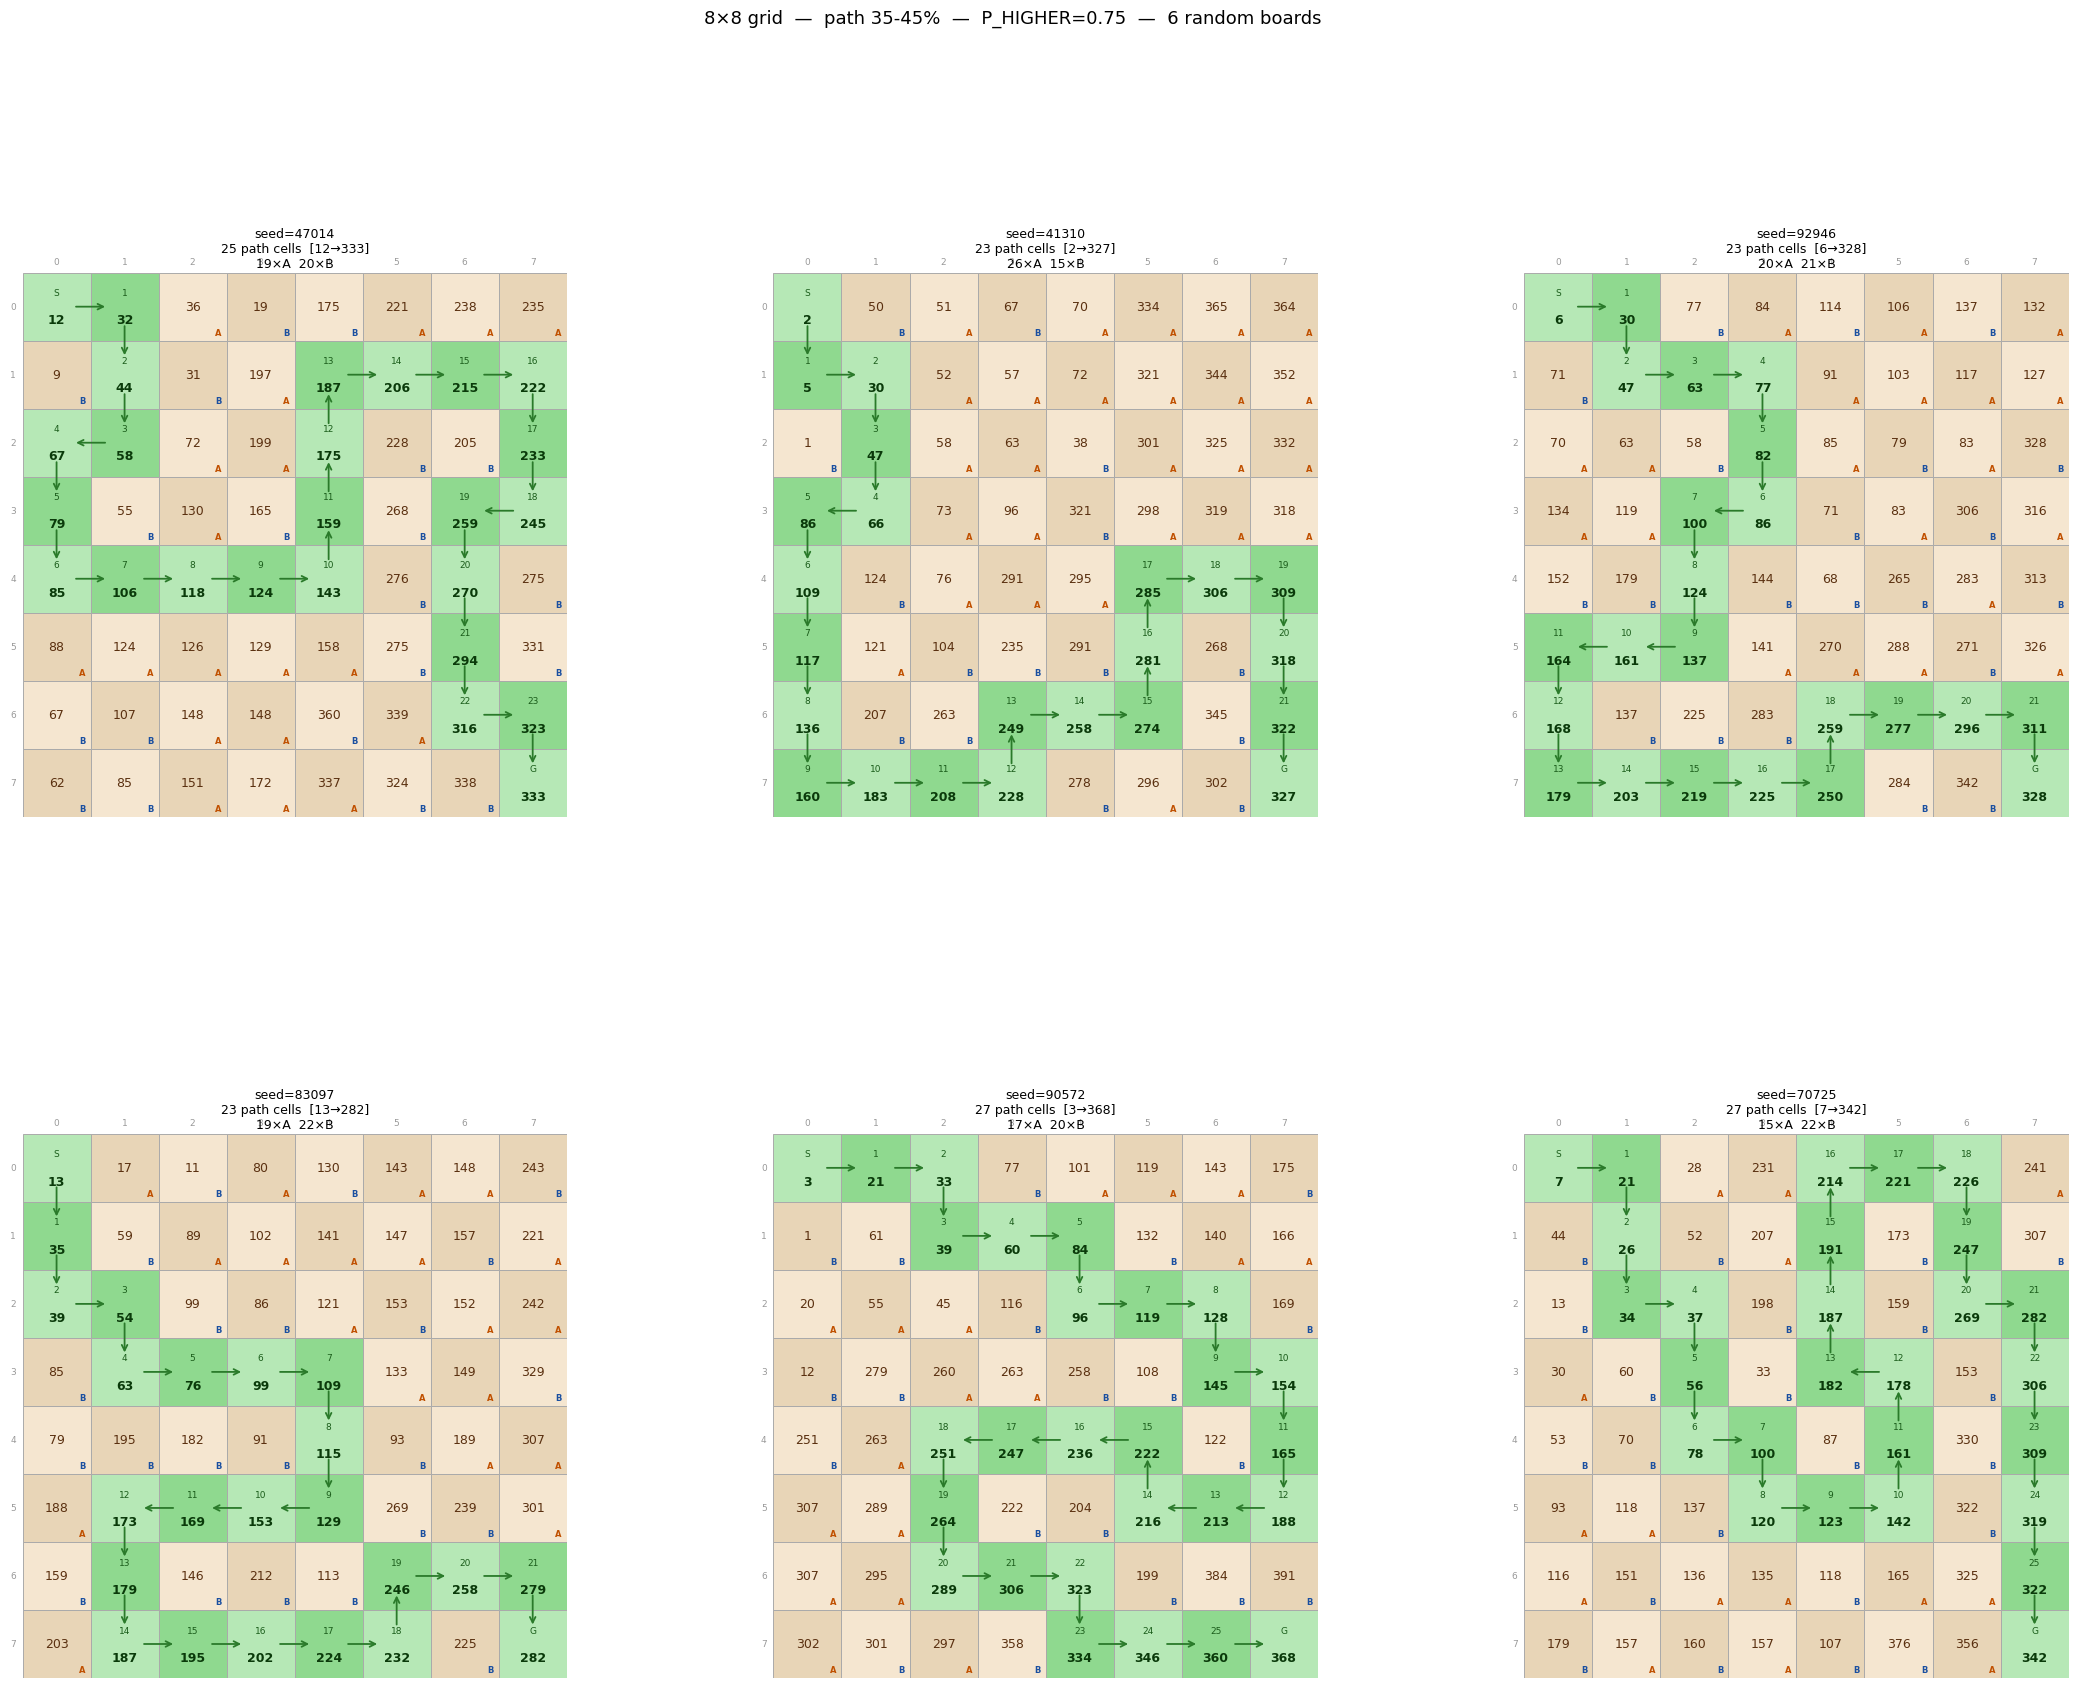

 #     seed   path     A     B  value range
 0    47014     25    19    20  [9–360]
 1    41310     23    26    15  [1–365]
 2    92946     23    20    21  [6–342]
 3    83097     23    19    22  [11–329]
 4    90572     27    17    20  [1–391]
 5    70725     27    15    22  [7–376]


In [34]:
# ── Controls — edit these and re-run ─────────────────────────────────────────
COLS             = 8    # number of columns
ROWS             = 8    # number of rows
MIN_PCT          = 0.35 # solution path min length as fraction of total fields
MAX_PCT          = 0.45 # solution path max length as fraction of total fields
GALLERY_P_HIGHER = 0.75  # 0.0–1.0 — prob of going higher off a single numbered neighbour
GLOBAL_MIN       = 1    # floor for all cell values
GLOBAL_MAX       = 999  # ceiling for all cell values

# ── Generate 6 fresh random boards ───────────────────────────────────────────
gallery = {}   # key: 0–5 → dict with all specs + results
for i in range(6):
    seed = random.randint(0, 99_999)
    result = generate_number_labyrinth_board(
        COLS, ROWS,
        min_pct    = MIN_PCT,
        max_pct    = MAX_PCT,
        p_higher   = GALLERY_P_HIGHER,
        global_min = GLOBAL_MIN,
        global_max = GLOBAL_MAX,
        rng        = random.Random(seed),
    )
    gallery[i] = dict(
        # generation specs
        seed       = seed,
        min_pct    = MIN_PCT,
        max_pct    = MAX_PCT,
        p_higher   = GALLERY_P_HIGHER,
        global_min = GLOBAL_MIN,
        global_max = GLOBAL_MAX,
        # board data (from generate_number_labyrinth_board)
        **result,
    )

# ── Display ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 3,
    figsize=(COLS * 3.3, ROWS * 2.3),
    gridspec_kw={'hspace': 0.55, 'wspace': 0.38},
)

for i, ax in enumerate(axes.flat):
    g   = gallery[i]
    cnt = Counter(v for k, v in g['labels'].items() if k not in set(g['path']))
    display_board(
        g['cols'], g['rows'], g['board'], g['path'], g['labels'],
        title=(
            f"seed={g['seed']}\n"
            f"{len(g['path'])} path cells  "
            f"[{g['path_values'][g['path'][0]]}→{g['path_values'][g['path'][-1]]}]\n"
            f"{cnt.get('A', 0)}×A  {cnt.get('B', 0)}×B"
        ),
        ax=ax,
    )

path_pct = f"{int(MIN_PCT*100)}-{int(MAX_PCT*100)}%"
fig.suptitle(
    f"{COLS}×{ROWS} grid  —  path {path_pct}  —  P_HIGHER={GALLERY_P_HIGHER}  —  6 random boards",
    fontsize=13, y=1.02,
)
plt.show()

# ── Print seed summary ────────────────────────────────────────────────────────
print(f"{'#':>2}  {'seed':>7}  {'path':>5}  {'A':>4}  {'B':>4}  value range")
for i, g in gallery.items():
    cnt   = Counter(v for k, v in g['labels'].items() if k not in set(g['path']))
    v_min = min(g['board'].values())
    v_max = max(g['board'].values())
    print(f"{i:>2}  {g['seed']:>7}  {len(g['path']):>5}  "
          f"{cnt.get('A',0):>4}  {cnt.get('B',0):>4}  [{v_min}–{v_max}]")

---
## 7 · Path analysis — all valid paths on a gallery board

Pick one of the six boards generated in section 6 with `GALLERY_PICK` (0–5) and re-run.  
The search enumerates all paths from `(0,0)`: a path is recorded when it reaches the goal  
`(cols-1, rows-1)` or hits a dead end (no adjacent cell with a higher value).

Stats reported:
- total paths, how many reach the goal, how many are dead-ends  
- path-length distribution  
- which fields are / are not on any path  
- for each field: how many paths pass through it

Each **goal-reaching path** is then shown on its own board (sorted by length, capped at `MAX_DISPLAY`).

Board #0  seed=47014  8×8  values [9–360]
───────────────────────────────────────────────────────
  Total paths from start         :         75
  Paths ending at goal           :          6
  Dead-end paths (not at goal)   :         69
  Fields in ≥1 path              :         53  (of 64)
  Fields in no path              :         11
    -> [(0, 1), (0, 6), (0, 7), (1, 3), (1, 6), (1, 7), (2, 1), (3, 0), (4, 0), (5, 7), (6, 2)]

  Path-length distribution:
    length   3 :        1  ██
    length   6 :        1  ██
    length   8 :        1  ██
    length  12 :        3  ███████
    length  13 :        9  █████████████████████
    length  14 :        8  ███████████████████
    length  15 :       17  ████████████████████████████████████████
    length  16 :        7  ████████████████
    length  17 :       17  ████████████████████████████████████████
    length  18 :        1  ██
    length  19 :        1  ██
    length  21 :        1  ██
    length  22 :        2  █████
    length  23

C:\Users\Alj\AppData\Local\Temp\ipykernel_18524\3366359826.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


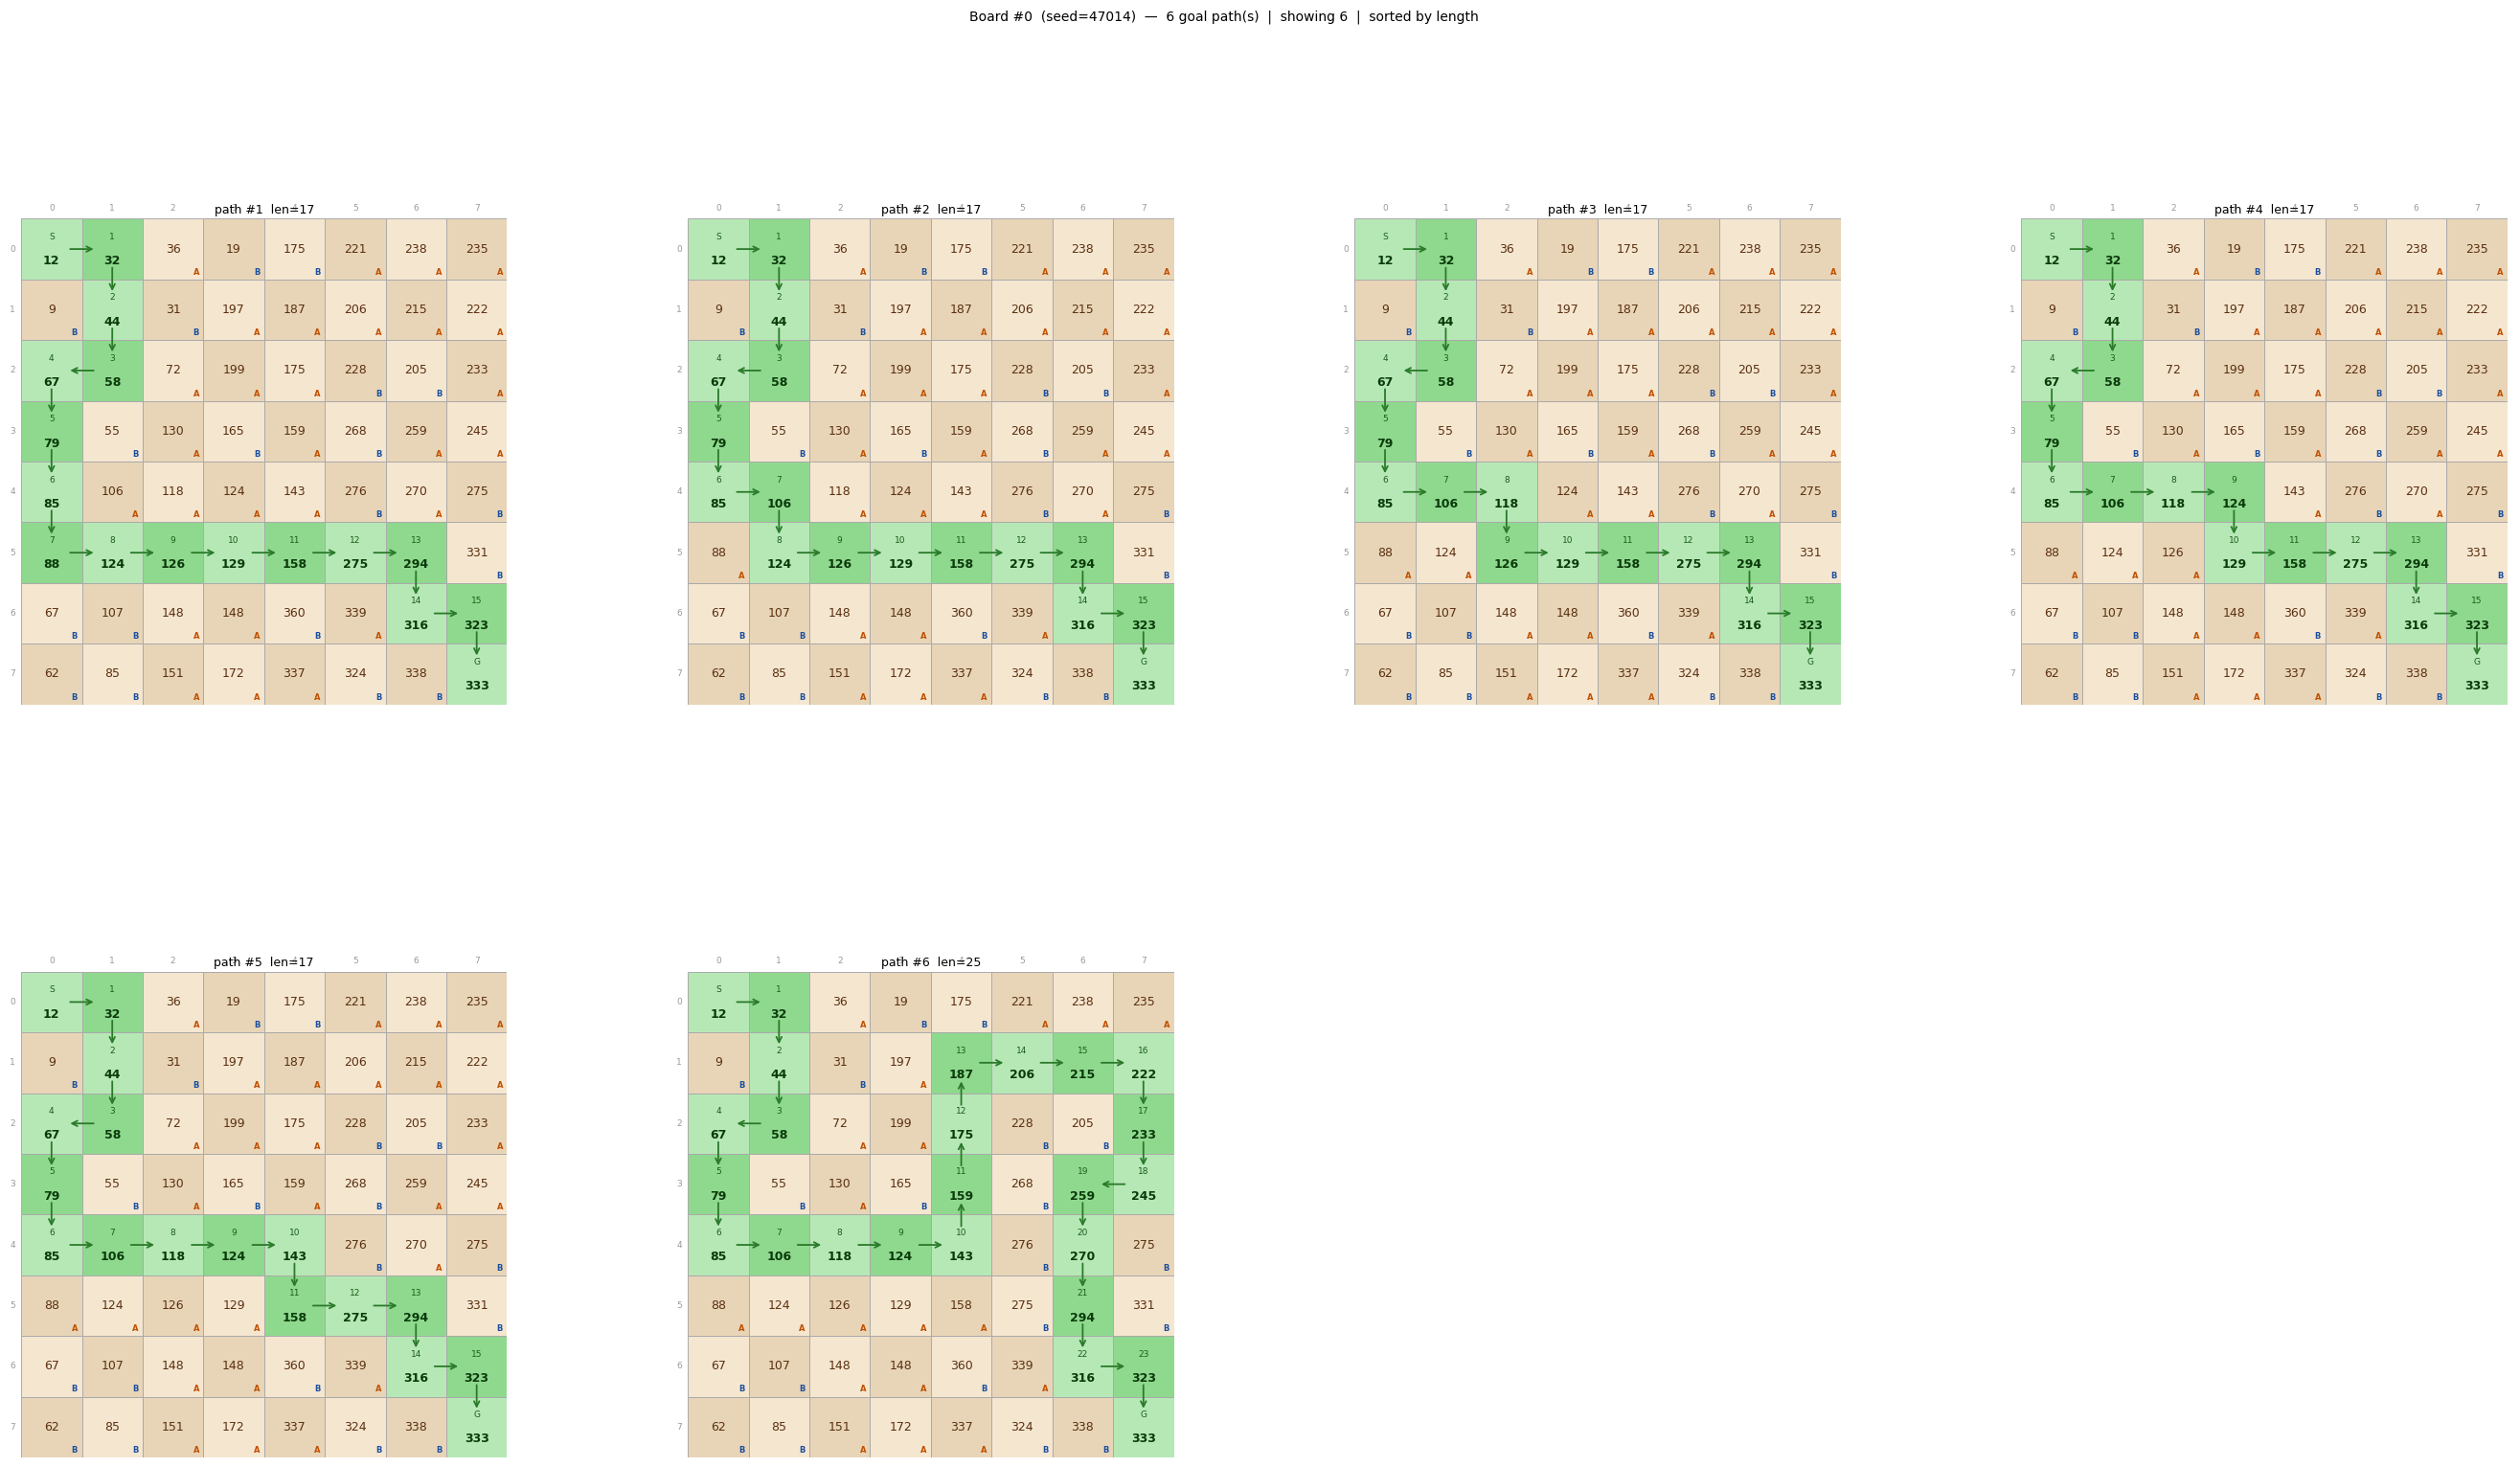

In [35]:
# ── Controls ──────────────────────────────────────────────────────────────────
GALLERY_PICK = 0    # 0–5: which board from the gallery above to analyse
MAX_DISPLAY  = 30   # max number of goal paths to plot (sorted by length)
N_COLS       = 4    # boards per row in the goal-paths figure

# ── Board setup ───────────────────────────────────────────────────────────────
g     = gallery[GALLERY_PICK]
cols, rows = g['cols'], g['rows']
board = g['board']
start = (0, 0)
goal  = (cols - 1, rows - 1)

def _higher_nbrs(cell):
    c, r = cell
    return [(c+dc, r+dr) for dc, dr in DIRS
            if 0 <= c+dc < cols and 0 <= r+dr < rows
            and board[(c+dc, r+dr)] > board[cell]]

# ── Iterative DFS — all paths from start ─────────────────────────────────────
all_paths = []
stack = [[start]]
while stack:
    path = stack.pop()
    current = path[-1]
    if current == goal:
        all_paths.append(tuple(path))
    else:
        nexts = _higher_nbrs(current)
        if nexts:
            for nc in nexts:
                stack.append(path + [nc])
        else:
            all_paths.append(tuple(path))

# ── Derived statistics ────────────────────────────────────────────────────────
path_lengths     = Counter(len(p) for p in all_paths)
goal_paths       = sorted([p for p in all_paths if p[-1] == goal], key=len)
field_path_count = Counter(cell for p in all_paths for cell in p)
paths_per_field  = Counter(field_path_count.values())
cells_in_any     = set(field_path_count)
cells_in_none    = {(c, r) for c in range(cols) for r in range(rows)} - cells_in_any

# ── Print stats ───────────────────────────────────────────────────────────────
W = 55
print(f"Board #{GALLERY_PICK}  seed={g['seed']}  {cols}×{rows}  "
      f"values [{min(board.values())}–{max(board.values())}]")
print("─" * W)
print(f"  Total paths from start         : {len(all_paths):>10,}")
print(f"  Paths ending at goal           : {len(goal_paths):>10,}")
print(f"  Dead-end paths (not at goal)   : {len(all_paths)-len(goal_paths):>10,}")
print(f"  Fields in ≥1 path              : {len(cells_in_any):>10,}  (of {cols*rows})")
print(f"  Fields in no path              : {len(cells_in_none):>10,}")
if cells_in_none:
    print(f"    -> {sorted(cells_in_none)}")

print()
print("  Path-length distribution:")
max_bar = 40
max_cnt = max(path_lengths.values())
for length in sorted(path_lengths):
    cnt = path_lengths[length]
    bar = '█' * round(max_bar * cnt / max_cnt)
    print(f"    length {length:3d} : {cnt:8,}  {bar}")

print()
print("  Fields by number of paths passing through:")
for n_paths in sorted(paths_per_field):
    n_fields = paths_per_field[n_paths]
    fields   = sorted(cell for cell, c in field_path_count.items() if c == n_paths)
    print(f"    {n_paths:8,} path(s) : {n_fields:3d} field(s)  {fields}")

# ── Plot each goal path on its own board ─────────────────────────────────────
to_plot = goal_paths[:MAX_DISPLAY]
n_plot  = len(to_plot)

if n_plot == 0:
    print("\nNo goal paths to display.")
else:
    if n_plot < len(goal_paths):
        print(f"\nShowing {n_plot} of {len(goal_paths)} goal paths (sorted by length).")

    n_rows = math.ceil(n_plot / N_COLS)
    cell_w = cols * 1.05
    cell_h = rows * 1.05
    fig, axes = plt.subplots(
        n_rows, N_COLS,
        figsize=(N_COLS * cell_w, n_rows * cell_h),
        gridspec_kw={'hspace': 0.55, 'wspace': 0.35},
        squeeze=False,
    )

    for idx, ax in enumerate(axes.flat):
        if idx < n_plot:
            gp = to_plot[idx]
            display_board(
                cols, rows, board,
                path=list(gp),
                labels=g['labels'],
                title=f"path #{idx+1}  len={len(gp)}",
                ax=ax,
            )
        else:
            ax.axis('off')   # hide unused subplots

    fig.suptitle(
        f"Board #{GALLERY_PICK}  (seed={g['seed']})  —  "
        f"{len(goal_paths)} goal path(s)  |  showing {n_plot}  |  sorted by length",
        fontsize=10, y=1.01,
    )
    plt.tight_layout()
    plt.show()

---
## 8 · Scaled analysis — path stats across solution-path length bands and P_HIGHER

For a chosen grid size the experiment sweeps two axes:

| Axis | Values |
|---|---|
| Solution-path length band | four 5 %-wide windows inside [35 %, 55 %] of total cells |
| P_HIGHER | 0.5 · 0.6 · 0.7 · 0.8 |

`N_BOARDS` boards are generated per combination (16 cells total).  
For each board the full path-count DFS is run (capped at `MAX_PATHS` to keep runtime bounded).

**Metrics collected per board:**
- `n_total` — total paths from start (goal-terminated + dead-ends)
- `n_goal` — paths that reach the goal cell
- `n_in_any` — fields visited by at least one path
- `med_len` — median length across all paths on that board

**Stats reported:** mean, median, Q25, Q75, min, max — printed as a table and shown as grouped box plots.

In [ ]:
import time

# ── Controls ──────────────────────────────────────────────────────────────────
ANALYSIS_COLS   = 5
ANALYSIS_ROWS   = 5
N_BOARDS        = 30        # boards sampled per (band, P_HIGHER) combination
MAX_PATHS       = 50_000    # DFS cap per board; boards that hit this are flagged
GLOBAL_MIN      = 1
GLOBAL_MAX      = 999

PATH_BANDS      = [(0.35, 0.40), (0.40, 0.45), (0.45, 0.50), (0.50, 0.55)]
P_HIGHER_VALUES = [0.5, 0.6, 0.7, 0.8]

BAND_LABELS = [f"{int(lo*100)}-{int(hi*100)}%" for lo, hi in PATH_BANDS]
METRICS     = ['n_total', 'n_goal', 'n_in_any', 'med_len']
METRIC_LABELS = {
    'n_total' : 'Total paths from start',
    'n_goal'  : 'Paths reaching goal',
    'n_in_any': 'Fields in ≥1 path',
    'med_len' : 'Median path length',
}

# ── Board path-count helper ───────────────────────────────────────────────────
def _analyse_board(cols, rows, board, max_paths):
    goal = (cols - 1, rows - 1)

    def higher_nbrs(cell):
        c, r = cell
        return [(c+dc, r+dr) for dc, dr in DIRS
                if 0 <= c+dc < cols and 0 <= r+dr < rows
                and board[(c+dc, r+dr)] > board[cell]]

    all_paths = []; truncated = False
    stack = [[(0, 0)]]
    while stack:
        if len(all_paths) >= max_paths:
            truncated = True; break
        path = stack.pop(); cur = path[-1]
        if cur == goal:
            all_paths.append(tuple(path))
        else:
            nexts = higher_nbrs(cur)
            if nexts:
                for nc in nexts: stack.append(path + [nc])
            else:
                all_paths.append(tuple(path))

    n_total  = len(all_paths)
    n_goal   = sum(1 for p in all_paths if p[-1] == goal)
    n_in_any = len({cell for p in all_paths for cell in p})
    med_len  = float(np.median([len(p) for p in all_paths])) if all_paths else 0.0
    return dict(n_total=n_total, n_goal=n_goal, n_in_any=n_in_any,
                med_len=med_len, truncated=truncated)

# ── Main sweep ────────────────────────────────────────────────────────────────
# data[band_idx][p_higher][metric] = list of N values
data = {
    bi: {p: {m: [] for m in METRICS} for p in P_HIGHER_VALUES}
    for bi in range(len(PATH_BANDS))
}
n_truncated = 0
t0 = time.time()

for bi, (lo_pct, hi_pct) in enumerate(PATH_BANDS):
    for p_higher in P_HIGHER_VALUES:
        attempts = 0
        while len(data[bi][p_higher]['n_total']) < N_BOARDS:
            attempts += 1
            rng  = random.Random()
            path = get_path(ANALYSIS_COLS, ANALYSIS_ROWS,
                            min_pct=lo_pct, max_pct=hi_pct, rng=rng)
            if path is None:
                continue
            pv       = assign_path_values(path, rng=rng)
            bd, _    = fill_board(ANALYSIS_COLS, ANALYSIS_ROWS, path, pv,
                                  p_higher=p_higher,
                                  global_min=GLOBAL_MIN, global_max=GLOBAL_MAX,
                                  rng=rng)
            stats = _analyse_board(ANALYSIS_COLS, ANALYSIS_ROWS, bd, MAX_PATHS)
            if stats['truncated']:
                n_truncated += 1
            for m in METRICS:
                data[bi][p_higher][m].append(stats[m])

elapsed = time.time() - t0
total   = len(PATH_BANDS) * len(P_HIGHER_VALUES) * N_BOARDS
print(f"{total} boards in {elapsed:.1f}s  |  "
      f"truncated at {MAX_PATHS:,}: {n_truncated} board(s)\n")

# ── Stats tables ──────────────────────────────────────────────────────────────
def _stats(vals):
    a = np.array(vals, dtype=float)
    return (np.mean(a), np.median(a),
            np.percentile(a, 25), np.percentile(a, 75),
            np.min(a), np.max(a))

P_COL_W = 22
for metric in METRICS:
    print(f"┌── {METRIC_LABELS[metric]} {'─'*(4*P_COL_W - len(METRIC_LABELS[metric]) - 4)}┐")
    header = f"  {'band':>8}  " + "".join(f"{'P='+str(p):>{P_COL_W}}" for p in P_HIGHER_VALUES)
    print(header)
    sub    = f"  {'':>8}  " + "".join(f"{'mean  med  [Q25-Q75]  min-max':>{P_COL_W}}" for _ in P_HIGHER_VALUES)
    print(sub)
    for bi, blbl in enumerate(BAND_LABELS):
        row = f"  {blbl:>8}  "
        for p_higher in P_HIGHER_VALUES:
            mn, med, q25, q75, lo, hi = _stats(data[bi][p_higher][metric])
            cell = f"{mn:5.0f} {med:4.0f} [{q25:.0f}-{q75:.0f}] {lo:.0f}-{hi:.0f}"
            row += f"{cell:>{P_COL_W}}"
        print(row)
    print()

# ── Box plots — 2×2 grid, one subplot per metric ─────────────────────────────
P_COLORS = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
N_BANDS  = len(PATH_BANDS)
N_P      = len(P_HIGHER_VALUES)
GROUP_W  = 0.8
BOX_W    = GROUP_W / N_P

fig, axes = plt.subplots(2, 2, figsize=(14, 9), gridspec_kw={'hspace': 0.45, 'wspace': 0.35})

for ax, metric in zip(axes.flat, METRICS):
    # one group of N_P boxes per band
    for pi, (p_higher, color) in enumerate(zip(P_HIGHER_VALUES, P_COLORS)):
        positions = [bi + (pi - (N_P-1)/2) * BOX_W for bi in range(N_BANDS)]
        vals      = [data[bi][p_higher][metric] for bi in range(N_BANDS)]
        bp = ax.boxplot(
            vals,
            positions=positions,
            widths=BOX_W * 0.85,
            patch_artist=True,
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(linewidth=0.8),
            capprops=dict(linewidth=0.8),
            flierprops=dict(marker='x', markersize=4, alpha=0.5),
            boxprops=dict(facecolor=color, alpha=0.65),
        )

    ax.set_xticks(range(N_BANDS))
    ax.set_xticklabels(BAND_LABELS, fontsize=8)
    ax.set_xlabel('Solution-path length band', fontsize=8)
    ax.set_title(METRIC_LABELS[metric], fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(labelsize=7)

# shared legend
handles = [mpatches.Patch(color=c, alpha=0.65, label=f'P={p}')
           for p, c in zip(P_HIGHER_VALUES, P_COLORS)]
fig.legend(handles=handles, loc='lower center', ncol=4,
           fontsize=8, title='P_HIGHER', title_fontsize=8,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    f"Scaled analysis — {ANALYSIS_COLS}×{ANALYSIS_ROWS} grid  "
    f"({N_BOARDS} boards per combination)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

---
## 9 · Uniqueness constraint — parameter search for low blocking rates

`global_min` and `global_max` are fixed. All step parameters are swept in a full grid search:

| Parameter | Search values |
|---|---|
| `path_min_step` | 1, 2, 3, 5 |
| `path_max_step` | 3, 5, 10, 20 |
| `fill_min_step` | 1, 2, 3 |
| `fill_max_step` | 5, 10, 20, 50 |

Only combinations where `path_max_step ≥ path_min_step` and `fill_max_step ≥ fill_min_step` are tested.  
For each valid combination the blocking rate is measured across all square board sizes **5×5 → 8×8** for both **weak** and **strong** uniqueness.  
Results are ranked by mean blocking rate across all board sizes.  
A marginal-effect plot shows how each individual parameter influences blocking rate.

Search grid: 1580 valid combos
Total trials: 158,000

Done in 42.1s

  STRONG uniqueness — top 15 combos (ranked by mean blocking rate)
  rank   pmin  pmax  fmin  fmax   mean%   5×5
  ──────────────────────────────────────────────────────────────────────
     1      4    14     1    10     0.0%     0.0%
     2      5    17     1     5     0.0%     0.0%
     3      8     9     1     5     0.0%     0.0%
     4      8    20     1    10     0.0%     0.0%
     5      1    20     1    10     1.0%     1.0%
     6      2     8     1    10     1.0%     1.0%
     7      3    14     1     5     1.0%     1.0%
     8      3    14     1    50     1.0%     1.0%
     9      3    30     1     5     1.0%     1.0%
    10      4    25     1    50     1.0%     1.0%
    11      4    30     2     5     1.0%     1.0%
    12      6    10     1    50     1.0%     1.0%
    13      6    25     3     5     1.0%     1.0%
    14      7    10     1    20     1.0%     1.0%
    15      7    14     1     5     1.0%     

C:\Users\Alj\AppData\Local\Temp\ipykernel_18524\3732258227.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


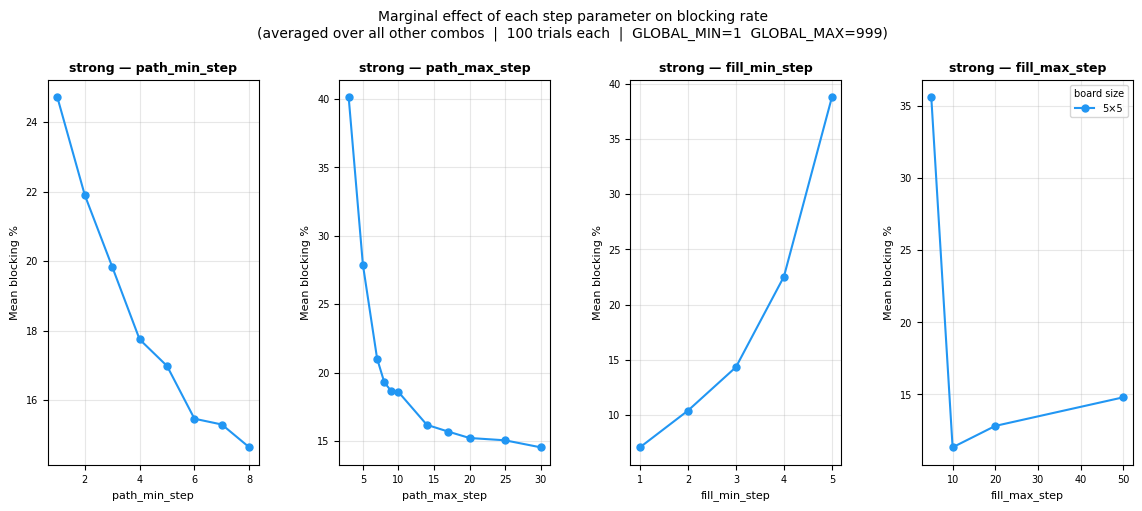

In [ ]:
import time
import itertools

# ── Fixed controls ─────────────────────────────────────────────────────────────
N_TRIALS    = 100       # trials per (combo, board_size, variant)
MIN_PCT     = 0.35
MAX_PCT     = 0.55
GLOBAL_MIN  = 1
GLOBAL_MAX  = 999
TOP_K       = 15        # how many best combos to display in ranking

BOARD_SIZES = [(5,5)] # [(5, 5), (6, 6), (7, 7), (8, 8)]
VARIANTS    = ['strong']   # ['weak', 'strong']

# ── Search grid ────────────────────────────────────────────────────────────────
PATH_MIN_STEP_VALUES = [1, 2, 3, 4, 5, 6, 7, 8]
PATH_MAX_STEP_VALUES = [3, 5, 7, 8, 9, 10, 14, 17, 20, 25, 30]
FILL_MIN_STEP_VALUES = [1, 2, 3, 4, 5]
FILL_MAX_STEP_VALUES = [5, 10, 20, 50]


## level 5 --> board size: 8x8:  path min= 7     path max= 30         fill min= 1        fill max= 40
## level 4 --> board size: 7x7:  path min= 6     path max= 25         fill min= 1        fill max= 30
## level 3 --> board size: 6x6:  path min= 5     path max= 20         fill min= 1        fill max= 20
## level 2 --> board size: 5x5:  path min= 4     path max= 14         fill min= 1        fill max= 10  
## level 1 --> board size: 4x4:  path min= 3     path max= 10          fill min= 1        fill max= 7  


# Only combos where max >= min for both step pairs
combos = [
    dict(path_min_step=pmin, path_max_step=pmax,
         fill_min_step=fmin, fill_max_step=fmax)
    for pmin, pmax in itertools.product(PATH_MIN_STEP_VALUES, PATH_MAX_STEP_VALUES)
    for fmin, fmax in itertools.product(FILL_MIN_STEP_VALUES, FILL_MAX_STEP_VALUES)
    if pmax >= pmin and fmax >= fmin
]
print(f"Search grid: {len(combos)} valid combos")
print(f"Total trials: {len(combos) * len(BOARD_SIZES) * len(VARIANTS) * N_TRIALS:,}\n")

# ── Sweep ──────────────────────────────────────────────────────────────────────
# blocking_rate[variant][combo_idx][(cols, rows)] = float in [0, 1]
blocking_rate = {v: [{} for _ in combos] for v in VARIANTS}

t0 = time.time()
for ci, params in enumerate(combos):
    for cols, rows in BOARD_SIZES:
        T  = cols * rows
        lo = math.floor(MIN_PCT * T)
        hi = math.floor(MAX_PCT * T)
        for variant in VARIANTS:
            n_ok = n_blocked = 0
            while n_ok + n_blocked < N_TRIALS:
                rng  = random.Random()
                path = generate_solution_path_dfs(
                    cols, rows, min_length=lo, max_length=hi, rng=rng
                )
                if path is None:
                    continue
                pv = assign_path_values(
                    path,
                    min_step = params['path_min_step'],
                    max_step = params['path_max_step'],
                    rng      = rng,
                )
                bd, _ = fill_board(
                    cols, rows, path, pv,
                    min_step   = params['fill_min_step'],
                    max_step   = params['fill_max_step'],
                    global_min = GLOBAL_MIN,
                    global_max = GLOBAL_MAX,
                    uniqueness = variant,
                    rng        = rng,
                )
                if bd is None:
                    n_blocked += 1
                else:
                    n_ok += 1
            blocking_rate[variant][ci][(cols, rows)] = n_blocked / (n_ok + n_blocked)

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")

# ── Rank by mean blocking rate across all board sizes ──────────────────────────
for variant in VARIANTS:
    print(f"\n{'='*72}")
    print(f"  {variant.upper()} uniqueness — top {TOP_K} combos (ranked by mean blocking rate)")
    print(f"{'='*72}")
    hdr_sizes = "   ".join(f"{c}×{r}" for c, r in BOARD_SIZES)
    print(f"  {'rank':>4}  {'pmin':>5} {'pmax':>5} {'fmin':>5} {'fmax':>5}  {'mean%':>6}   {hdr_sizes}")
    print(f"  {'─'*70}")

    ranked = sorted(
        range(len(combos)),
        key=lambda ci: np.mean([blocking_rate[variant][ci][(c, r)] for c, r in BOARD_SIZES])
    )
    for rank, ci in enumerate(ranked[:TOP_K], 1):
        p         = combos[ci]
        mean_rate = np.mean([blocking_rate[variant][ci][(c, r)] for c, r in BOARD_SIZES]) * 100
        per_size  = "   ".join(f"{blocking_rate[variant][ci][(c,r)]*100:5.1f}%" for c, r in BOARD_SIZES)
        print(f"  {rank:>4}  {p['path_min_step']:>5} {p['path_max_step']:>5} "
              f"{p['fill_min_step']:>5} {p['fill_max_step']:>5}  "
              f"{mean_rate:>6.1f}%   {per_size}")

# ── Marginal effect plots ──────────────────────────────────────────────────────
PARAM_AXES = [
    ('path_min_step', PATH_MIN_STEP_VALUES),
    ('path_max_step', PATH_MAX_STEP_VALUES),
    ('fill_min_step', FILL_MIN_STEP_VALUES),
    ('fill_max_step', FILL_MAX_STEP_VALUES),
]
SIZE_COLORS = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

fig, axes = plt.subplots(
    len(VARIANTS), len(PARAM_AXES),
    figsize=(14, 5 * len(VARIANTS)),
    gridspec_kw={'hspace': 0.55, 'wspace': 0.38},
    squeeze=False,
)

for vi, variant in enumerate(VARIANTS):
    for pi, (param_name, param_vals) in enumerate(PARAM_AXES):
        ax = axes[vi][pi]
        for si, (cols, rows) in enumerate(BOARD_SIZES):
            means = []
            for pv in param_vals:
                rates = [
                    blocking_rate[variant][ci][(cols, rows)]
                    for ci, p in enumerate(combos)
                    if p[param_name] == pv
                ]
                means.append(np.mean(rates) * 100)
            ax.plot(param_vals, means, 'o-', color=SIZE_COLORS[si],
                    label=f'{cols}×{rows}', linewidth=1.5, markersize=5)

        ax.set_xlabel(param_name, fontsize=8)
        ax.set_ylabel('Mean blocking %', fontsize=8)
        ax.set_title(f'{variant} — {param_name}', fontsize=9, fontweight='bold')
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)
        if pi == len(PARAM_AXES) - 1:
            ax.legend(fontsize=7, title='board size', title_fontsize=7)

fig.suptitle(
    f"Marginal effect of each step parameter on blocking rate\n"
    f"(averaged over all other combos  |  {N_TRIALS} trials each  |  "
    f"GLOBAL_MIN={GLOBAL_MIN}  GLOBAL_MAX={GLOBAL_MAX})",
    fontsize=10, y=1.02,
)
plt.tight_layout()
plt.show()

In [58]:
# ── Top-20 combo detail view ───────────────────────────────────────────────────
TOP_N = 20

for variant in VARIANTS:
    ranked = sorted(
        range(len(combos)),
        key=lambda ci: np.mean([blocking_rate[variant][ci][(c, r)] for c, r in BOARD_SIZES])
    )

    rows_data = []
    for rank, ci in enumerate(ranked[:TOP_N], 1):
        p = combos[ci]
        per_size = {f"{c}×{r}": blocking_rate[variant][ci][(c, r)] * 100
                    for c, r in BOARD_SIZES}
        mean_rate = np.mean(list(per_size.values()))
        rows_data.append(dict(
            rank=rank,
            path_min=p['path_min_step'],
            path_max=p['path_max_step'],
            fill_min=p['fill_min_step'],
            fill_max=p['fill_max_step'],
            mean=mean_rate,
            **per_size,
        ))

    import pandas as pd
    df = pd.DataFrame(rows_data).set_index('rank')
    df.columns.name = None

    # Format percentages
    pct_cols = [f"{c}×{r}" for c, r in BOARD_SIZES] + ['mean']

    df[pct_cols] = df[pct_cols].apply(lambda col: col.apply(lambda x: f"{x:.1f}%"))

    print(f"\n{'━'*72}")
    print(f"  {variant.upper()} uniqueness — top {TOP_N} combos")
    print(f"{'━'*72}")
    print(df.to_string())
    print()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STRONG uniqueness — top 20 combos
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
      path_min  path_max  fill_min  fill_max  mean   5×5
rank                                                    
1            4        14         1        10  0.0%  0.0%
2            5        17         1         5  0.0%  0.0%
3            8         9         1         5  0.0%  0.0%
4            8        20         1        10  0.0%  0.0%
5            1        20         1        10  1.0%  1.0%
6            2         8         1        10  1.0%  1.0%
7            3        14         1         5  1.0%  1.0%
8            3        14         1        50  1.0%  1.0%
9            3        30         1         5  1.0%  1.0%
10           4        25         1        50  1.0%  1.0%
11           4        30         2         5  1.0%  1.0%
12           6        10         1        50  1.0%  1.0%
13           6     